# Tiny_Tau_v3 - Tau Universe Asymmetry Exploration
- Hamiltonian: Z + 0.142857 X (compact potential + 1/7 mode)
- Ansatz: n_local RY reps=3, single qubit
- Fixed phase: rz(2π/7) for Tau harmonic
- Result v2: Energy penalty + extreme |1⟩ bias (~99.8%)
Goal: Modulate / understand / scale the asymmetry

In [14]:
# Correct imports for Qiskit 2.3.0 + qiskit-algorithms 0.4.0
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# CPU simulator (fast for small systems)
simulator = AerSimulator(method='statevector')

print("Imports successful — ready for Hamiltonian and VQE!")

Imports successful — ready for Hamiltonian and VQE!


In [15]:
# Tau-inspired Hamiltonian
# Z = compact circle potential
# X = small asymmetry from 142857 / 1/7 mode
hamiltonian = SparsePauliOp.from_list([("Z", 1.0), ("X", 0.142857)])
print("Hamiltonian defined:", hamiltonian)

Hamiltonian defined: SparsePauliOp(['Z', 'X'],
              coeffs=[1.      +0.j, 0.142857+0.j])


In [16]:
from qiskit.circuit.library import n_local

# Create single-qubit ansatz with Tau + Berard elements
ansatz = n_local(
    num_qubits=1,
    rotation_blocks='ry',             # RY rotations only
    entanglement_blocks=[],           # No entanglement → must be empty list, not None
    reps=3,
    entanglement='full'               # Required parameter, ignored for 1 qubit
)

# Tau harmonic phase (compact circle influence)
ansatz.rz(2 * np.pi / 7, 0)           # ≈ 0.8976 rad - 2π/7

# Berard constant rotation (1.054 rad) - test modulation of asymmetry
ansatz.ry(1.054, 0)

print("Ansatz created successfully with Tau phase + Berard rotation")
print("Circuit depth:", ansatz.depth())
print("Number of parameters:", ansatz.num_parameters)

# Optional: visualize the circuit (uncomment if matplotlib is installed)
# ansatz.draw('mpl')

Ansatz created successfully with Tau phase + Berard rotation
Circuit depth: 6
Number of parameters: 4


In [17]:
# Insert Tau harmonic phase — 2π / 7 ≈ 0.8975979010256552 radians
ansatz.rz(2 * np.pi / 7, 0)   # fixed phase on qubit 0

In [18]:
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA   # ← add this import if missing

# Define the optimizer (this is what was missing)
optimizer = COBYLA(maxiter=120)

estimator = StatevectorEstimator()

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

result = vqe.compute_minimum_eigenvalue(operator=hamiltonian)

print(f"Ground state energy: {result.eigenvalue.real:.6f}")
print("Optimal parameters:", result.optimal_parameters)

Ground state energy: -0.830058
Optimal parameters: {ParameterVectorElement(θ[0]): np.float64(2.843853483377024), ParameterVectorElement(θ[1]): np.float64(-3.0448453228833534), ParameterVectorElement(θ[2]): np.float64(-6.827965778235796), ParameterVectorElement(θ[3]): np.float64(-3.2071514206567957)}


In [19]:
qc = ansatz.assign_parameters(result.optimal_parameters)
qc.measure_all()

counts = simulator.run(qc, shots=4096).result().get_counts()
print("Measurement counts:", counts)

Measurement counts: {'0': 559, '1': 3537}


High-shot counts: {'0': 2161, '1': 14223}


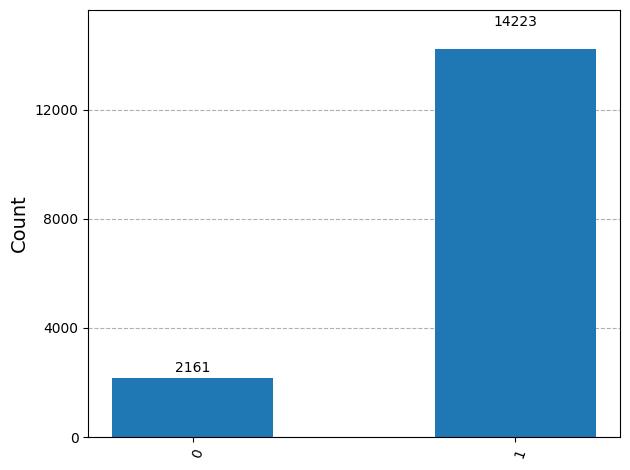

In [20]:
from qiskit.visualization import plot_histogram

# Re-measure with more shots for confidence
qc = ansatz.assign_parameters(result.optimal_parameters)
qc.measure_all()

counts_high = simulator.run(qc, shots=16384).result().get_counts()
print("High-shot counts:", counts_high)

# Plot
plot_histogram(counts_high)